In [ ]:

#pip install pandas numpy nltk matplotlib seaborn wordcloud scikit-learn jupyter

     -------------------------------------- 14.6/14.6 MB 638.1 kB/s eta 0:00:00
     ------------------------------------ 261.9/261.9 kB 520.0 kB/s eta 0:00:00
     ------------------------------------ 139.8/139.8 kB 594.3 kB/s eta 0:00:00
     -------------------------------------- 12.5/12.5 MB 421.5 kB/s eta 0:00:00
     ---------------------------------------- 2.2/2.2 MB 590.4 kB/s eta 0:00:00
     ------------------------------------ 914.9/914.9 kB 705.7 kB/s eta 0:00:00
  Using cached httpx-0.28.1-py3-none-any.whl (73 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
     -------------------------------------- 59.8/59.8 kB 799.8 kB/s eta 0:00:00
     -------------------------------------- 77.5/77.5 kB 862.5 kB/s eta 0:00:00
     ------------------------------------ 391.9/391.9 kB 642.5 kB/s eta 0:00:00
     ------------------------------------ 107.7/107.7 kB 691.4 kB/s eta 0:00:00
     -------------------------------------- 78.5/78.5 kB 483.8 kB/s eta 0:00:00
     --------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress t

In [1]:
import pandas as pd

df = pd.read_csv("sentiment analysis.csv")

df.head()

,Complaint ID,Category,Sub Category,Grievance Date,Ward Name,Grievance Status,Staff Remarks,Staff Name
0,20771690,Electrical,Street Light Not Working,2025-06-19 10:39:00.000000000,Jagajeevanram Nagar,Registered,1st Assignment Based on Ward Mapping,syed zameer/JE
1,20771689,Electrical,Street Light Not Working,2025-06-19 10:36:00.000000000,Kammanahalli,Registered,1st Assignment Based on Ward Mapping,Vinay Kumar/AE
2,20771688,Solid Waste (Garbage) Related,Garbage dump,2025-06-19 10:35:00.000000000,Banaswadi,Registered,1st Assignment Based on Ward Mapping,Marshal Ward No 27/Marshal
3,20771687,Electrical,Street Light Not Working,2025-06-19 10:34:00.000000000,Gandhi Nagar,Registered,1st Assignment Based on Ward Mapping,syed zameer/JE
4,20771686,Solid Waste (Garbage) Related,Garbage dump,2025-06-19 10:34:00.000000000,Kumaraswamy Layout,Registered,1st Assignment Based on Ward Mapping,Marshal Ward No 181/Marshal


In [2]:

df.shape

df.columns

df.info()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126974 entries, 0 to 126973
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Complaint ID      126974 non-null  int64 
 1   Category          126974 non-null  object
 2   Sub Category      126974 non-null  object
 3   Grievance Date    126974 non-null  object
 4   Ward Name         126974 non-null  object
 5   Grievance Status  126920 non-null  object
 6   Staff Remarks     126920 non-null  object
 7   Staff Name        126920 non-null  object
dtypes: int64(1), object(7)
memory usage: 7.8+ MB


Complaint ID         0
Category             0
Sub Category         0
Grievance Date       0
Ward Name            0
Grievance Status    54
Staff Remarks       54
Staff Name          54
dtype: int64

In [3]:

df.dropna(inplace=True)

df.drop_duplicates(inplace=True)

df.shape

(126920, 8)

In [4]:
import re

def clean_text(text):
    
    text = str(text).lower()
    
    text = re.sub(r'http\S+', '', text)
    
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

In [5]:
df['clean_text'] = df['Sub Category'].apply(clean_text)

df[['Sub Category','clean_text']].head()

,Sub Category,clean_text
0,Street Light Not Working,street light not working
1,Street Light Not Working,street light not working
2,Garbage dump,garbage dump
3,Street Light Not Working,street light not working
4,Garbage dump,garbage dump


In [6]:
import nltk

nltk.download('punkt')

nltk.download('stopwords')

[nltk_data] Error loading punkt: <urlopen error [WinError 10054] An
[nltk_data]     existing connection was forcibly closed by the remote
[nltk_data]     host>
[nltk_data] Error loading stopwords: <urlopen error [WinError 10054]
[nltk_data]     An existing connection was forcibly closed by the
[nltk_data]     remote host>


False

In [7]:
import re

def clean_text(text):
    
    text = str(text).lower()
    
    text = re.sub(r'http\S+', '', text)
    
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

df['clean_text'] = df['Sub Category'].apply(clean_text)

df[['Sub Category', 'clean_text']].head()

,Sub Category,clean_text
0,Street Light Not Working,street light not working
1,Street Light Not Working,street light not working
2,Garbage dump,garbage dump
3,Street Light Not Working,street light not working
4,Garbage dump,garbage dump


In [8]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    
    words = word_tokenize(text)
    
    filtered = [word for word in words if word not in stop_words]
    
    return " ".join(filtered)

df['clean_text'] = df['clean_text'].apply(remove_stopwords)

df[['Sub Category','clean_text']].head()

,Sub Category,clean_text
0,Street Light Not Working,street light working
1,Street Light Not Working,street light working
2,Garbage dump,garbage dump
3,Street Light Not Working,street light working
4,Garbage dump,garbage dump


In [9]:

nltk.download('wordnet')

[nltk_data] Error loading wordnet: <urlopen error [WinError 10054] An
[nltk_data]     existing connection was forcibly closed by the remote
[nltk_data]     host>


False

In [10]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    
    words = text.split()
    
    words = [lemmatizer.lemmatize(word) for word in words]
    
    return " ".join(words)

df['clean_text'] = df['clean_text'].apply(lemmatize_text)

df[['Sub Category','clean_text']].head()

,Sub Category,clean_text
0,Street Light Not Working,street light working
1,Street Light Not Working,street light working
2,Garbage dump,garbage dump
3,Street Light Not Working,street light working
4,Garbage dump,garbage dump


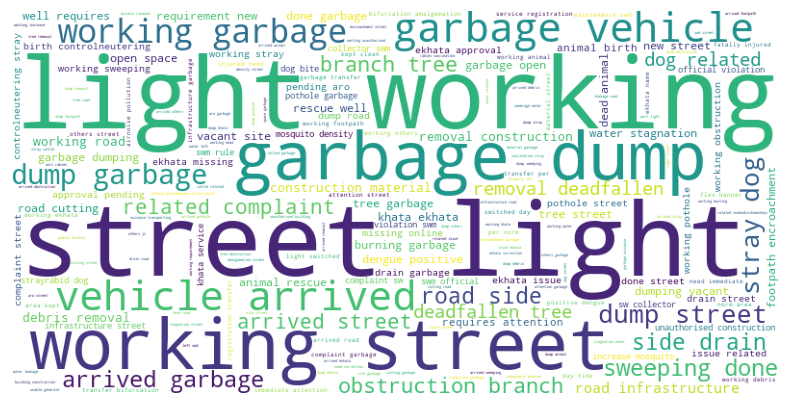

In [11]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['clean_text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis('off')

plt.show()


In [12]:
from collections import Counter

all_words = " ".join(df['clean_text']).split()

word_freq = Counter(all_words)

word_freq.most_common(10)

[('light', 41828),
 ('street', 41725),
 ('working', 40106),
 ('garbage', 32154),
 ('dump', 16129),
 ('vehicle', 12130),
 ('arrived', 12130),
 ('road', 7404),
 ('tree', 6040),
 ('dog', 5222)]

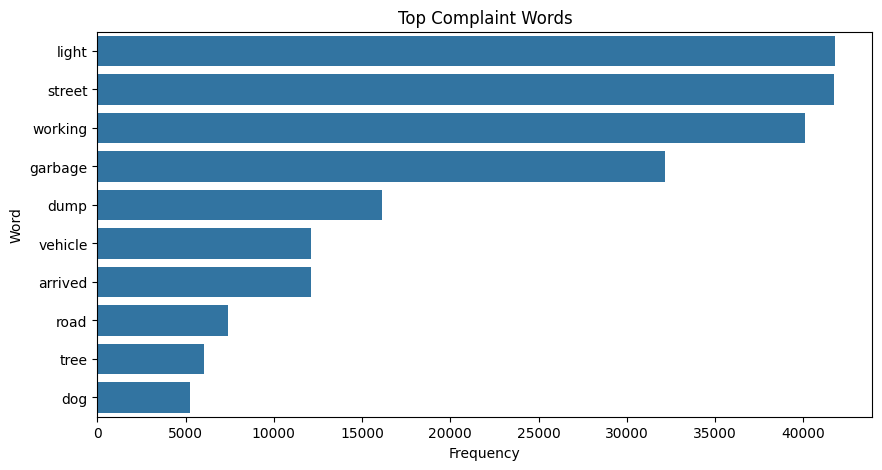

In [13]:
import seaborn as sns

top_words = pd.DataFrame(
    word_freq.most_common(10),
    columns=['Word','Frequency']
)

plt.figure(figsize=(10,5))

sns.barplot(
    x='Frequency',
    y='Word',
    data=top_words
)

plt.title("Top Complaint Words")

plt.show()


Topic Modeling & Department Prediction

STEP 1 — Features and Target

In [16]:
X = df['clean_text']

y = df['Category']

STEP 2 — TF-IDF Vectorization

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_vectorized = tfidf.fit_transform(X)

print(X_vectorized.shape)

(126920, 327)


STEP 3 — Train Test Split

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)

print(X_test.shape)

(101536, 327)
(25384, 327)


Logistic Regression

In [33]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

Accuracy

In [35]:
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy :", lr_accuracy)

Logistic Regression Accuracy : 0.9982272297510243


In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                               precision    recall  f1-score   support

                Advertisement       1.00      1.00      1.00       127
         BBMP Election Branch       0.00      0.00      0.00         1
               CORONA COVID19       0.00      0.00      0.00         6
                  Call Center       1.00      0.36      0.53        11
     E khata / Khata services       1.00      1.00      1.00       866
                    Education       0.00      0.00      0.00         2
                   Electrical       1.00      1.00      1.00      8441
                       Estate       0.00      0.00      0.00         8
                       Forest       1.00      1.00      1.00      1232
                  Health Dept       1.00      1.00      1.00       692
               Indira Canteen       1.00      0.79      0.89        39
       Information Technology       1.00      1.00      1.00        16
                        Lakes       1.00      1.00      1.00        60
     

c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [34]:
from sklearn.metrics import confusion_matrix

lr_cm = confusion_matrix(y_test, lr_pred)

print("Logistic Regression Confusion Matrix:\n")

print(lr_cm)

Logistic Regression Confusion Matrix:

[[ 127    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0]
 [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    1]
 [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    2    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    4]
 [   0    0    0    4    0    0    0    0    0    0    0    0    0    0
     0    7    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0]
 [   0    0    0    0  866    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0]
 [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    1    0    0    0    0    0    0
     0 

Random Forest Modeel

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)


Evaluation Metrics

In [38]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy :", rf_accuracy)

Random Forest Accuracy : 0.9987787582729278


In [39]:
print(classification_report(y_test, rf_pred))

                               precision    recall  f1-score   support

                Advertisement       1.00      1.00      1.00       127
         BBMP Election Branch       1.00      1.00      1.00         1
               CORONA COVID19       1.00      0.67      0.80         6
                  Call Center       1.00      0.36      0.53        11
     E khata / Khata services       1.00      1.00      1.00       866
                    Education       1.00      1.00      1.00         2
                   Electrical       1.00      1.00      1.00      8441
                       Estate       1.00      0.12      0.22         8
                       Forest       1.00      1.00      1.00      1232
                  Health Dept       1.00      1.00      1.00       692
               Indira Canteen       1.00      0.79      0.89        39
       Information Technology       1.00      1.00      1.00        16
                        Lakes       1.00      1.00      1.00        60
     

In [40]:
rf_cm = confusion_matrix(y_test, rf_pred)

print("Random Forest Confusion Matrix:\n")

print(rf_cm)

Random Forest Confusion Matrix:

[[ 127    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0]
 [   0    1    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0]
 [   0    0    4    0    0    0    0    0    0    0    0    0    0    0
     0    2    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0]
 [   0    0    0    4    0    0    0    0    0    0    0    0    0    0
     0    7    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0]
 [   0    0    0    0  866    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0]
 [   0    0    0    0    0    2    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0  